# Hierarchical Clustering: A Comprehensive Guide

Hierarchical Clustering builds a hierarchy of clusters either by merging smaller clusters into larger ones (agglomerative, bottom-up) or by splitting larger clusters into smaller ones (divisive, top-down).

In this notebook, we'll cover:
1. Basic concepts of Hierarchical Clustering
2. Data preparation and visualization
3. Model implementation from scratch (Agglomerative)
4. Using scikit-learn for Hierarchical Clustering
5. Dendrogram interpretation and model evaluation

# Simple Explanation: What Does the Code Below Do?

Agglomerative hierarchical clustering works like building a family tree:
1. Start with every data point as its own cluster.
2. Find the two closest clusters and merge them.
3. Repeat until only one cluster remains.

The result is a **dendrogram** — a tree diagram showing how clusters were merged. You can 'cut' the tree at any height to get any number of clusters!

Linkage criteria (how to measure distance between clusters):
- **Single**: Distance between closest points in each cluster.
- **Complete**: Distance between farthest points in each cluster.
- **Average**: Average distance between all pairs of points.
- **Ward**: Minimizes variance within clusters (most common).

Here's what the code does:
1. Implements basic agglomerative clustering from scratch.
2. Uses scipy and sklearn for full hierarchical clustering.
3. Visualizes dendrograms to interpret cluster structure.

In short: Hierarchical clustering doesn't require specifying K in advance — the dendrogram reveals natural groupings!

In [1]:
import os
import sys

venv_dir = 'ml_env'
if not os.path.exists(venv_dir):
    os.system(f'{sys.executable} -m venv {venv_dir}')
    print(f'Virtual environment created at {venv_dir}')
else:
    print(f'Virtual environment already exists at {venv_dir}')

pip_path = os.path.join(venv_dir, 'Scripts', 'pip')
if sys.platform == 'win32':
    pip_path += '.exe'

if os.path.exists(pip_path):
    os.system(f'"{pip_path}" install numpy pandas matplotlib seaborn scikit-learn scipy')
    print('Required libraries installed.')
else:
    print('Could not find pip. Please check your Python installation.')

Virtual environment already exists at ml_env
Could not find pip. Please check your Python installation.


# 1. Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 2. Generating Sample Data

Dataset shape: (150, 2)


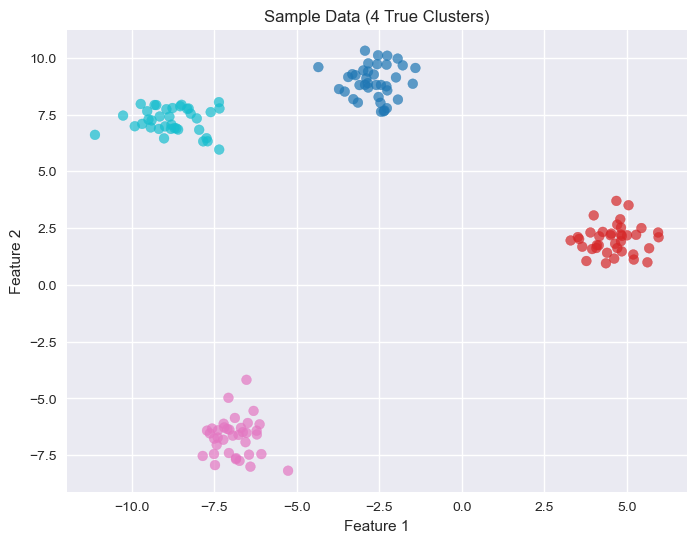

In [3]:
X, y_true = make_blobs(n_samples=150, centers=4, cluster_std=0.7, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Dataset shape:', X.shape)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='tab10', alpha=0.7, s=50)
plt.title('Sample Data (4 True Clusters)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

# 3. Implementing Agglomerative Clustering from Scratch

Simple version using single-linkage (nearest neighbor) approach.

In [4]:
def agglomerative_scratch(X, n_clusters, linkage='single'):
    """Simple agglomerative clustering from scratch."""
    n = len(X)
    # Each point starts as its own cluster
    clusters = {i: [i] for i in range(n)}
    
    def cluster_distance(c1_indices, c2_indices):
        dists = [np.linalg.norm(X[i] - X[j]) 
                 for i in c1_indices for j in c2_indices]
        if linkage == 'single':
            return min(dists)
        elif linkage == 'complete':
            return max(dists)
        else:  # average
            return np.mean(dists)

    while len(clusters) > n_clusters:
        # Find closest pair of clusters
        min_dist = float('inf')
        merge_pair = None
        keys = list(clusters.keys())
        for i in range(len(keys)):
            for j in range(i+1, len(keys)):
                d = cluster_distance(clusters[keys[i]], clusters[keys[j]])
                if d < min_dist:
                    min_dist = d
                    merge_pair = (keys[i], keys[j])

        # Merge the two closest clusters
        c1, c2 = merge_pair
        clusters[c1] = clusters[c1] + clusters[c2]
        del clusters[c2]

    # Assign labels
    labels = np.zeros(n, dtype=int)
    for cluster_id, (_, indices) in enumerate(clusters.items()):
        for idx in indices:
            labels[idx] = cluster_id
    return labels

labels_scratch = agglomerative_scratch(X_scaled[:50], n_clusters=4, linkage='single')  # small subset for speed
print('Scratch clustering done!')
print(f'Cluster sizes: {np.bincount(labels_scratch)}')

Scratch clustering done!
Cluster sizes: [12 14 12 12]


# 4. Using Scipy and Scikit-learn — Full Hierarchical Clustering

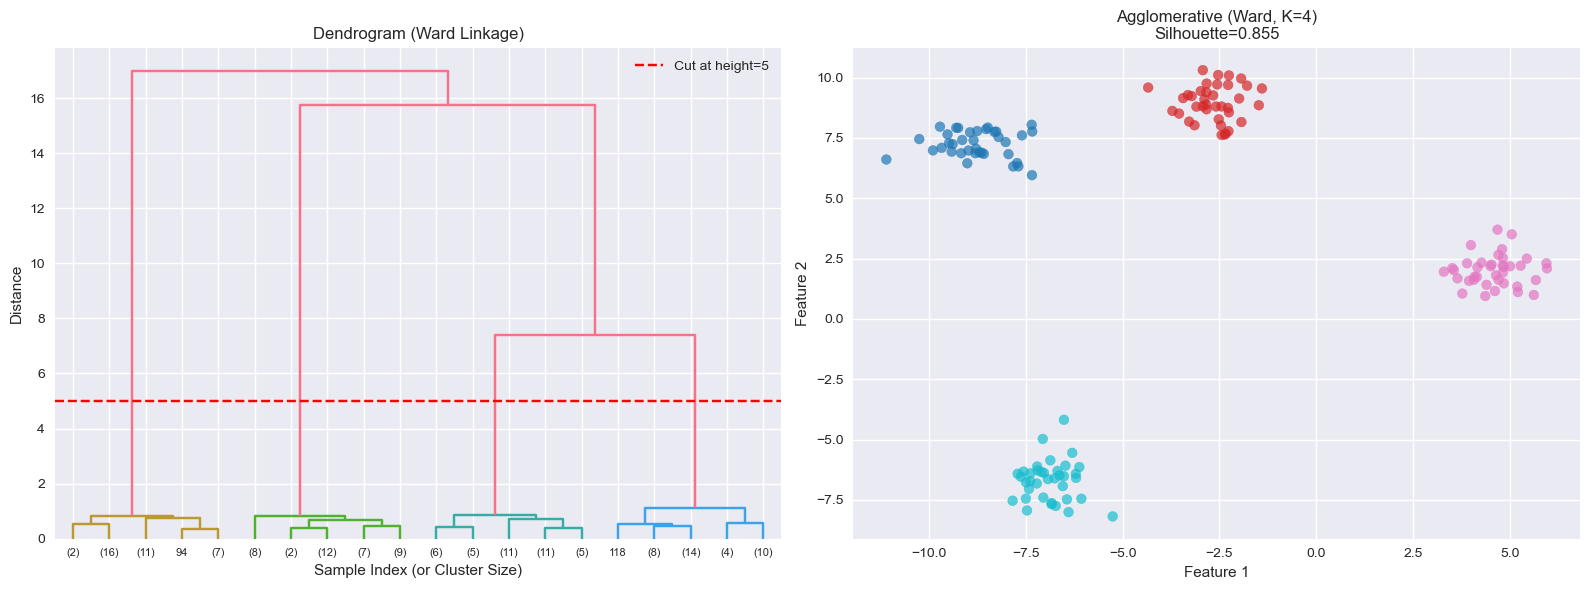

In [5]:
# Build dendrogram using scipy (Ward linkage)
Z = linkage(X_scaled, method='ward')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Dendrogram
dendrogram(Z, truncate_mode='lastp', p=20, ax=axes[0], leaf_font_size=8, color_threshold=5)
axes[0].set_title('Dendrogram (Ward Linkage)')
axes[0].set_xlabel('Sample Index (or Cluster Size)')
axes[0].set_ylabel('Distance')
axes[0].axhline(y=5, color='red', linestyle='--', label='Cut at height=5')
axes[0].legend()

# Clustering result with AgglomerativeClustering
ag = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels = ag.fit_predict(X_scaled)

axes[1].scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', alpha=0.7, s=50)
axes[1].set_title(f'Agglomerative (Ward, K=4)\nSilhouette={silhouette_score(X_scaled, labels):.3f}')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

# 5. Model Evaluation — Comparing Linkage Methods

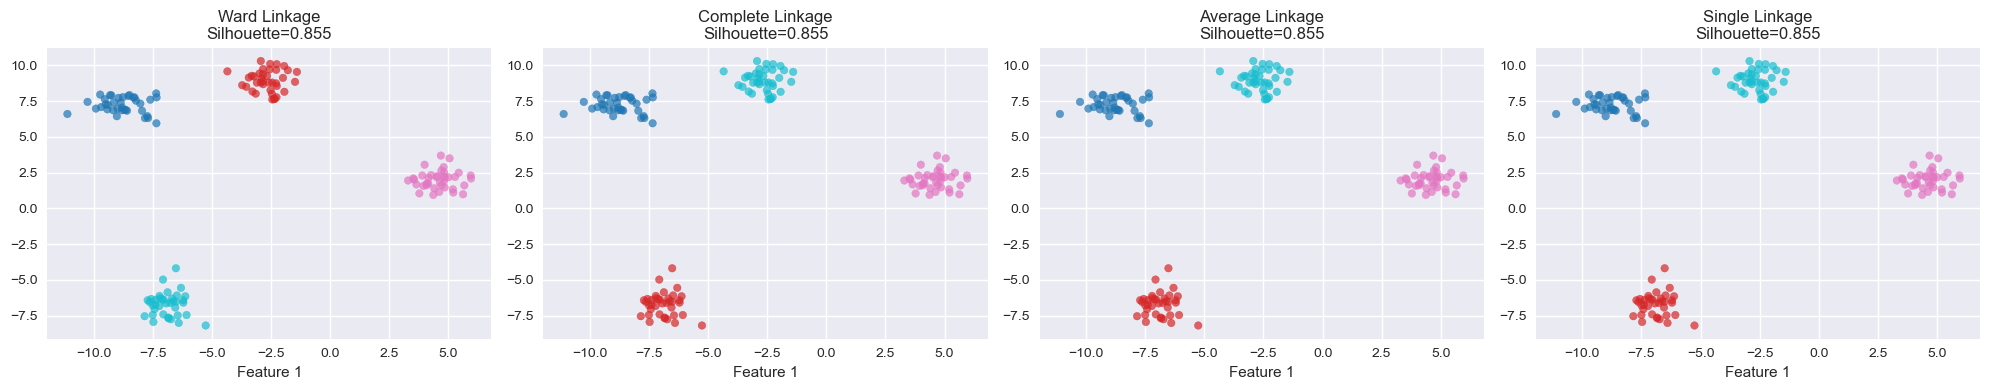


Key Insights:
- Ward linkage minimizes within-cluster variance (usually best for compact clusters).
- Single linkage can produce "chaining" effects (elongated clusters).
- Hierarchical clustering doesn't require specifying K in advance.
- The dendrogram reveals the natural hierarchy of the data.


In [6]:
linkage_methods = ['ward', 'complete', 'average', 'single']
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, method in zip(axes, linkage_methods):
    if method == 'ward':
        ag = AgglomerativeClustering(n_clusters=4, linkage=method, metric='euclidean')
    else:
        ag = AgglomerativeClustering(n_clusters=4, linkage=method, metric='euclidean')
    labels_m = ag.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels_m)
    ax.scatter(X[:, 0], X[:, 1], c=labels_m, cmap='tab10', alpha=0.7, s=30)
    ax.set_title(f'{method.capitalize()} Linkage\nSilhouette={sil:.3f}')
    ax.set_xlabel('Feature 1')

plt.tight_layout()
plt.show()

print('\nKey Insights:')
print('- Ward linkage minimizes within-cluster variance (usually best for compact clusters).')
print('- Single linkage can produce "chaining" effects (elongated clusters).')
print('- Hierarchical clustering doesn\'t require specifying K in advance.')
print('- The dendrogram reveals the natural hierarchy of the data.')

# Conclusions and Key Takeaways
Hierarchical Clustering builds a tree-like hierarchy of clusters (a dendrogram). It doesn't require specifying the number of clusters upfront and provides deep insight into the structure and relationship of the data groupings.
- **Agglomerative**: The most common approach ("bottom-up"). Starts with every point as its own cluster and progressively merges the closest pairs until one massive cluster remains.
- **Dendrograms**: The visual output of this algorithm, allowing you to choose the exact number of clusters post-training by drawing a horizontal "cut" line.
- **Linkage Criteria**: Determines how the distance between *clusters* is calculated (e.g., Ward, Complete, Single, Average).

# Pros and Cons
**Pros:**
- No need to guess the optimal 'K' beforehand; you examine the dendrogram and decide later.
- Produces a highly interpretable visual hierarchy mapping out the entire dataset's relationships.
- Different linkage methods offer flexibility to find differently shaped clusters.

**Cons:**
- O(N³) or O(N² log N) time complexity makes it fundamentally unscalable for massive datasets.
- Extremely sensitive to noise and outliers (especially with Single Linkage).
- Once a merge happens, it cannot be undone. "Greedy" decisions early on might lead to poor overarching clusters later.

# 15 Interview Questions and Answers

1. **What are the two main types of Hierarchical Clustering?**
   *Answer*: Agglomerative (bottom-up: starts with N clusters and merges them) and Divisive (top-down: starts with 1 cluster and recursively splits it down).

2. **What is a Dendrogram?**
   *Answer*: A tree-like diagram that records the sequences of merges or splits. The y-axis typically represents the distance or dissimilarity between the clusters being merged.

3. **How do you determine the final clusters from a dendrogram?**
   *Answer*: By drawing a horizontal line across the dendrogram at a specific distance threshold. The number of vertical lines intersected by that horizontal cut equals the number of final clusters.

4. **What is "Linkage" in Hierarchical clustering?**
   *Answer*: The criterion used to define the distance between two *clusters* (sets of points), deciding which two clusters should be merged next.

5. **What is Single Linkage?**
   *Answer*: Defines the distance between two clusters as the shortest distance between any single point in cluster A and any single point in cluster B. Prone to "chaining" anomalies.

6. **What is Complete Linkage (Maximum Linkage)?**
   *Answer*: Defines the distance between two clusters as the maximum distance between any point in cluster A and any point in cluster B. Tends to produce tightly bound, spherical clusters.

7. **What is Average Linkage?**
   *Answer*: Defines the distance as the average distance between all pairs of points across both clusters. It's a compromise between Single and Complete linkage.

8. **What is Ward's Method?**
   *Answer*: It merges the two clusters that will result in the smallest increase in the total within-cluster variance (Sum of Squared Errors). This generally yields the most evenly sized, balanced clusters and is highly popular.

9. **Does Hierarchical Clustering require the number of clusters (K) as an input?**
   *Answer*: No. It builds the full hierarchy. You only specify 'K' or a distance threshold implicitly *after* the algorithm has run to extract flat partitions.

10. **Why is Hierarchical Clustering rarely used on datasets with 100,000+ rows?**
    *Answer*: Because computing and storing the necessary distance matrix (N x N) has an exorbitant memory requirement, O(N²), and the linkage merging process takes roughly O(N³), which crashes most standard machines.

11. **How is the distance matrix initially calculated?**
    *Answer*: Usually using Euclidean distance, Manhattan distance, or Cosine similarity, depending on the data type.

12. **What happens to outliers in Hierarchical Clustering?**
    *Answer*: They tend to skew the results. With Single linkage, outliers easily get chained into the model. Usually, outliers end up merging at the very top of the dendrogram as isolated standalone branches.

13. **Can you "undo" a poor merge step?**
    *Answer*: No. The algorithm is strictly greedy. If a mathematically optimal local merge happens at step 3, but it ruins the global clustering pattern at step 50, the algorithm cannot backtrack to fix it.

14. **How do you choose where to cut the dendrogram safely?**
    *Answer*: Look for the tallest vertical line that is not intersected by any horizontal merging lines. Cutting through that long unbroken vertical line typically yields the most natural global cluster division.

15. **How does Hierarchical differ from K-Means regarding cluster shapes?**
    *Answer*: While K-Means assumes fundamentally spherical clusters, Hierarchical clustering with Single Linkage can follow arbitrary, non-linear shapes (like a crescent moon) if the points are chained closely enough together.
